# 04 — Active clients by country and town

Active clients (`role_id = 6`, `is_active = 1`, `soft_delete = 0`) grouped by `country` and `town`, ordered by count descending. Mirrors `docs/Client_Querires.md` §1.1.

In [1]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd

load_dotenv()

engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASS')}"
    f"@{os.getenv('DB_ANALYST_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

In [2]:
query = """
SELECT country, town, COUNT(*) AS active_clients
FROM users
WHERE role_id = 6
  AND is_active = 1
  AND soft_delete = 0
GROUP BY country, town
ORDER BY active_clients DESC;
"""

df = pd.read_sql(query, engine)
print(df)

     country           town  active_clients
0         UK         London              15
1         RO           iasi               9
2         US    Los Angeles               6
3         GR         Athens               6
4         UK      Liverpool               5
5         FR          Paris               4
6    Italian           iasi               4
7         ES         Madrid               4
8         IE         Dublin               4
9         TR       Istanbul               4
10        SE      Stockholm               4
11        IT           Roma               3
12        BG          Sofia               3
13        IT        Bologna               2
14   Italian      Bucharest               2
15   Italian      bucuresti               2
16   Italian           roma               2
17        ES      Barcelona               2
18   Romania           iasi               2
19        RO      Bucharest               2
20        US        Detroit               2
21        UK     Birmingham     

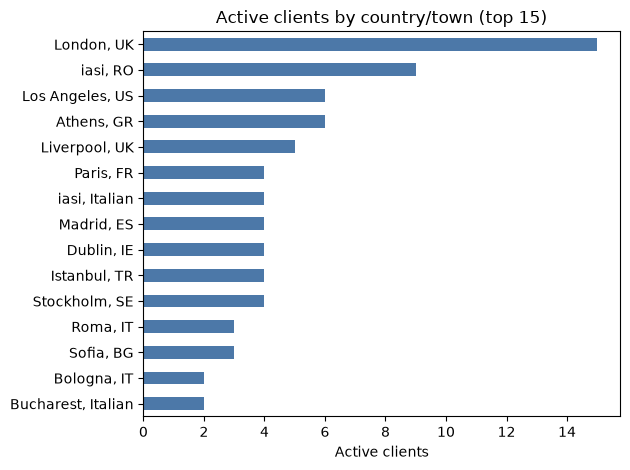

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt

top = df.head(15).assign(label=lambda d: d["town"] + ", " + d["country"])
top.plot(kind="barh", x="label", y="active_clients", legend=False, color="#4C78A8")
plt.gca().invert_yaxis()
plt.title("Active clients by country/town (top 15)")
plt.xlabel("Active clients")
plt.ylabel("")
plt.tight_layout()
plt.show()